## Homework 3: Tree-based models

In [2]:
# suppress all warning messages in the code
import warnings
warnings.filterwarnings("ignore")

### Problem 1

Plot the decision tree corresponding to the feature partition. The problem statement is given in the slides `homework2_problem1.pptx`. Complete the decision tree and upload it to the cell below.

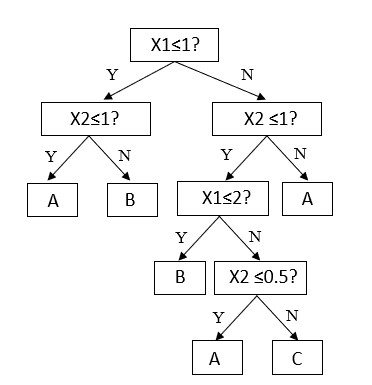

In [4]:
# upload the decision tree by running the following code

from IPython import display
display.Image("./decision_tree.jpg")  # assume that the image is in the same directory as the notebook

### Problem 2

Suppose we produce 10 bootstrapped samples from a data set containing red and green classes. We then apply a classification tree to
each bootstrapped sample and, for a specific value of X, produce 10
estimates of P (Class is Red|X): 0.1, 0.15, 0.2, 0.2, 0.55, 0.6, 0.6, 0.65, 0.7, and 0.75.

There are two common ways to combine these results together into a
single class prediction. One is the majority vote approach. The second approach is to classify based on the average probability. In this example, what is the final classification under each
of these two approaches?

**Your answer here**

The 10 probabilities are:
P(Class is Red|X) = 0.1, 0.15, 0.2, 0.2, 0.55, 0.6, 0.6, 0.65, 0.7, 0.75

**Majority vote**

For majority vote, each estimate is classified as Red if the probability is >0.5, otherwise Green.

So, from the probabilities, we get:

* Green: 0.1, 0.15, 0.2, 0.2 (4 votes)
* Red: 0.55, 0.6, 0.6, 0.65, 0.7, 0.75 (6 votes)

So under majority vote approach, the final class is **Red**. (Ans.)

**Average probability**

For average probability, compute the mean:

$$\frac{0.1+0.15+0.2+0.2+0.55+0.6+0.6+0.65+0.7+0.75}{10}
= \frac{4.5}{10} = 0.45$$

Since 0.45 < 0.5, the final class under average probability approach is **Green**.  (Ans.)






### Problem 3

We will seek to predict `Sales` in the `Carseats` data using regression trees and related approaches,
treating the response as a quantitative variable. 

It is a data frame with 400 observations on the following 11 variables.

- Sales: 
Unit sales (in thousands) at each location

- CompPrice: 
Price charged by competitor at each location

- Income: 
Community income level (in thousands of dollars)

- Advertising: 
Local advertising budget for company at each location (in thousands of dollars)

- Population: 
Population size in region (in thousands)

- Price: 
Price company charges for car seats at each site

- ShelveLoc: 
A factor with levels Bad, Good and Medium indicating the quality of the shelving location for the car seats at each site

- Age: 
Average age of the local population

- Education: 
Education level at each location

- Urban: 
A factor with levels No and Yes to indicate whether the store is in an urban or rural location

- US: 
A factor with levels No and Yes to indicate whether the store is in the US or not

Reference: https://rdrr.io/cran/ISLR/man/Carseats.html#heading-0


### Part 0
- Data preprocessing: Convert the categorical features to numeric ones.
- Split the data set into a training set and a test set. 

In [18]:
import pandas as pd
from sklearn.model_selection import train_test_split

carseats = pd.read_csv('./Carseats.csv', index_col=False)

# check the data
carseats.info()

carseats.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Sales        400 non-null    float64
 1   CompPrice    400 non-null    int64  
 2   Income       400 non-null    int64  
 3   Advertising  400 non-null    int64  
 4   Population   400 non-null    int64  
 5   Price        400 non-null    int64  
 6   ShelveLoc    400 non-null    object 
 7   Age          400 non-null    int64  
 8   Education    400 non-null    int64  
 9   Urban        400 non-null    object 
 10  US           400 non-null    object 
dtypes: float64(1), int64(7), object(3)
memory usage: 34.5+ KB


,Sales,CompPrice,Income,Advertising,Population,Price,ShelveLoc,Age,Education,Urban,US
0,9.50,138,73,11,276,120,Bad,42,17,Yes,Yes
1,11.22,111,48,16,260,83,Good,65,10,Yes,Yes
2,10.06,113,35,10,269,80,Medium,59,12,Yes,Yes
3,7.40,117,100,4,466,97,Medium,55,14,Yes,Yes
4,4.15,141,64,3,340,128,Bad,38,13,Yes,No


In [35]:

# Split features and response
X = carseats.drop(columns=["Sales"])
y = carseats["Sales"]

# Convert the categorcal features to numerical ones uning one-hot encoding
# ShelveLoc, Urban, and US are categorical
X = pd.get_dummies(X, drop_first=True)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

#### Part 1
- Fit a decision (regression) tree. Use cross-validation in order to determine the optimal value of `max_depth`. 
- Print the R-square on training and testing set
- Plot the tree


Best max_depth: 8
Training R²: 0.9422
Testing R²: 0.4184


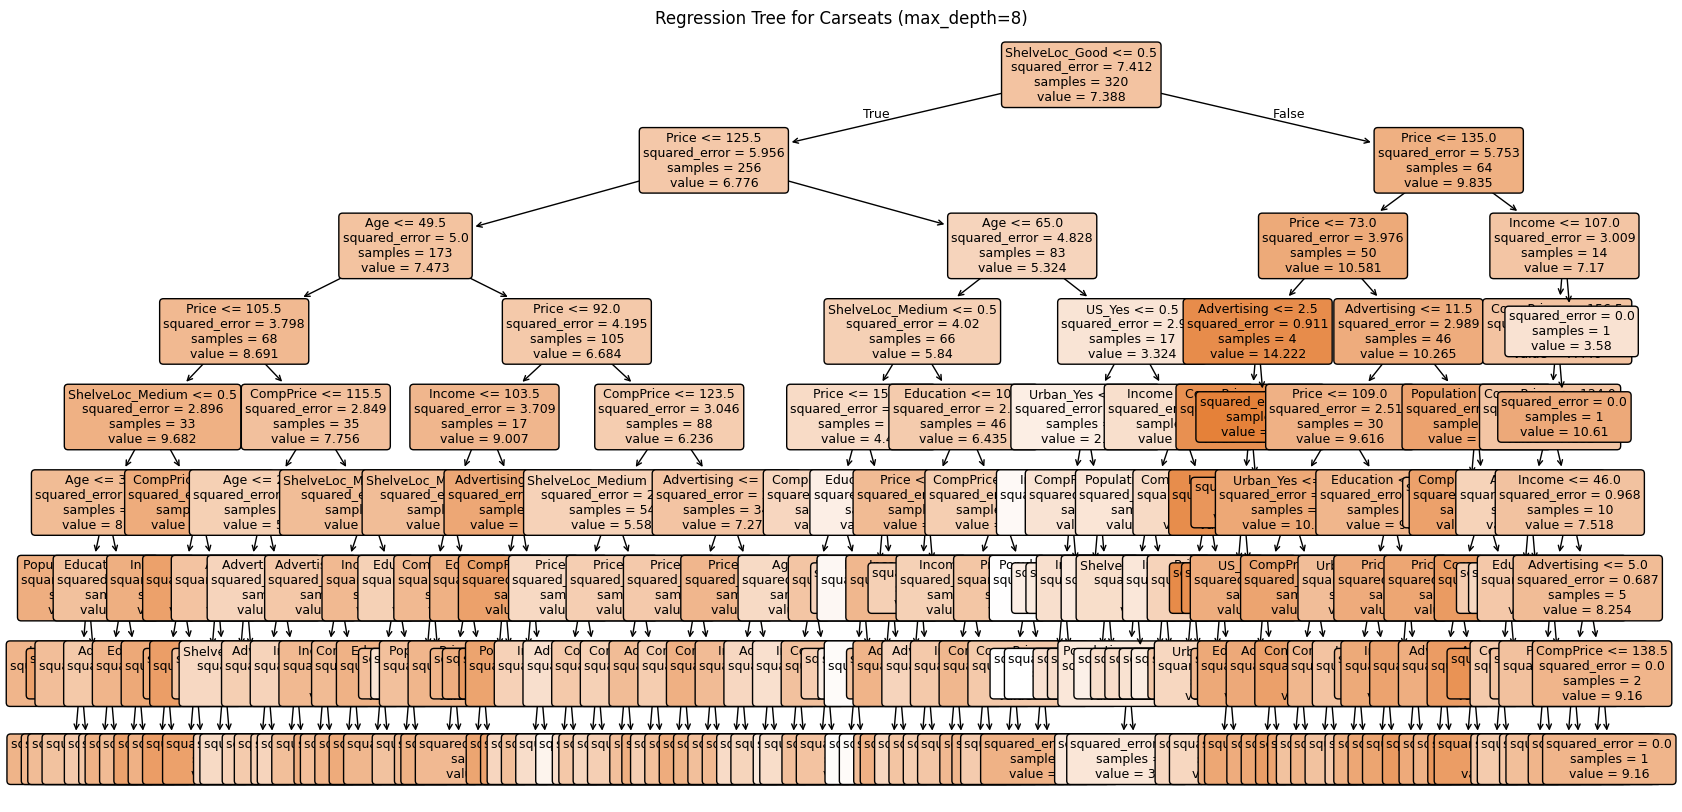

In [36]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.metrics import r2_score

# Cross-validation to find optimal max_depth
depth_range = range(1, 11)
cv_scores = []

for depth in depth_range:
    tree = DecisionTreeRegressor(max_depth=depth, random_state=42)
    scores = cross_val_score(
        tree,
        X_train,
        y_train,
        cv=5,
        scoring="r2"
    )
    cv_scores.append(scores.mean())

best_depth = depth_range[cv_scores.index(max(cv_scores))]
print("Best max_depth:", best_depth)

# Fit final model
final_tree = DecisionTreeRegressor(max_depth=best_depth, random_state=42)
final_tree.fit(X_train, y_train)

# Predictions
y_train_pred = final_tree.predict(X_train)
y_test_pred = final_tree.predict(X_test)

# R-squared
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

print("Training R²:", round(train_r2, 4))
print("Testing R²:", round(test_r2, 4))

# Plot the tree
plt.figure(figsize=(20, 10))
plot_tree(
    final_tree,
    feature_names=X.columns,
    filled=True,
    rounded=True,
    fontsize=9
)
plt.title(f"Regression Tree for Carseats (max_depth={best_depth})")
plt.show()

#### Part 2

- Use the bagging approach based on a decision tree for regression in order to analyze this data. Use 5-fold CV to determine the optimal value of `n_estimator`. Print the R-square on training and testing set.
- Plot the variable importance to determine which variables are most important.


Best n_estimators: 230
Best CV R²: 0.6096
Training R²: 0.9561
Testing R²: 0.6906

Variable Importance:
             Feature  Importance
4              Price    0.312331
7     ShelveLoc_Good    0.196213
5                Age    0.120318
0          CompPrice    0.095715
2        Advertising    0.083443
8   ShelveLoc_Medium    0.059493
1             Income    0.050774
3         Population    0.039929
6          Education    0.030098
9          Urban_Yes    0.006382
10            US_Yes    0.005306


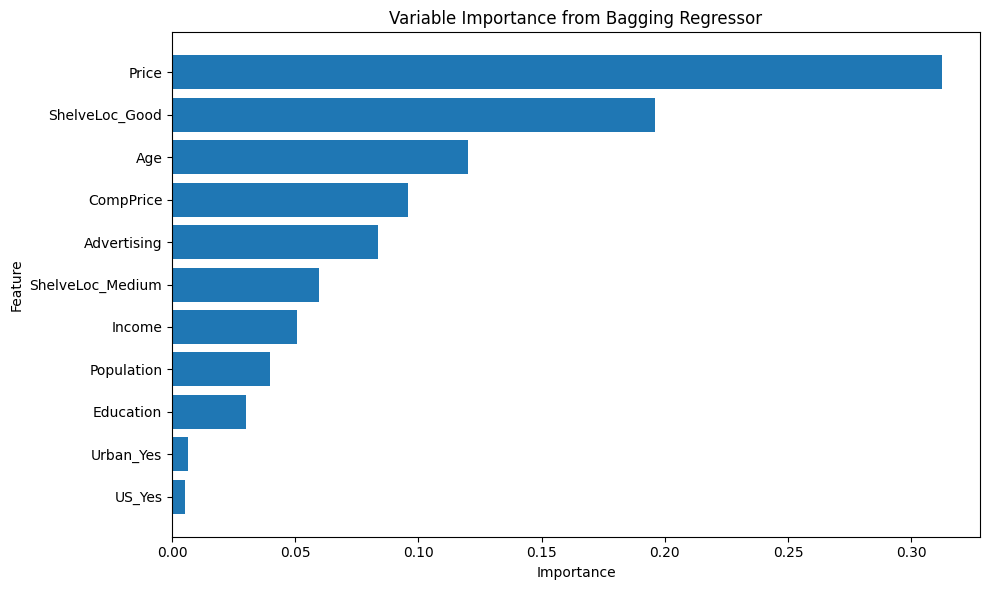

In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import BaggingRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import r2_score

# X_train, X_test, y_train, y_test are assumed to be ready

# Define the bagging model
bag_model = BaggingRegressor(
    estimator=DecisionTreeRegressor(random_state=42),
    random_state=42,
    n_jobs=-1
)

# Search over a range of estimator values at intervals of 10
param_grid = {
    "n_estimators": list(range(10, 301, 5))
}

# Perform 5-fold cross-validation
grid_search = GridSearchCV(
    estimator=bag_model,
    param_grid=param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

# Fit grid search
grid_search.fit(X_train, y_train)

# Extract the best model
best_n = grid_search.best_params_["n_estimators"]
final_bag = grid_search.best_estimator_

print("Best n_estimators:", best_n)
print("Best CV R²:", round(grid_search.best_score_, 4))

# Predict on training and test sets
y_train_pred = final_bag.predict(X_train)
y_test_pred = final_bag.predict(X_test)

# Compute R²
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

print("Training R²:", round(train_r2, 4))
print("Testing R²:", round(test_r2, 4))

# Average feature importance across all trees
feature_importances = np.mean(
    [tree.feature_importances_ for tree in final_bag.estimators_],
    axis=0
)

# Create importance table
importance_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": feature_importances
}).sort_values(by="Importance", ascending=False)

print("\nVariable Importance:")
print(importance_df)

# Plot variable importance
plt.figure(figsize=(10, 6))
plt.barh(importance_df["Feature"], importance_df["Importance"])
plt.gca().invert_yaxis()
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Variable Importance from Bagging Regressor")
plt.tight_layout()
plt.show()


#### Part 3

- Use random forests to analyze this data. Use 5-fold CV to determine the optimal value of `n_estimator` and `max_depth`. Print the R-square on training and testing set
- Plot the variable importance to determine which variables are most important.

Best parameters: {'estimator__max_depth': 12, 'n_estimators': 230}
Best CV R²: 0.6104
Training R²: 0.9558
Testing R²: 0.6902

Variable Importance:
             Feature  Importance
4              Price    0.312562
7     ShelveLoc_Good    0.196430
5                Age    0.120324
0          CompPrice    0.095693
2        Advertising    0.083345
8   ShelveLoc_Medium    0.059712
1             Income    0.050582
3         Population    0.039930
6          Education    0.029895
9          Urban_Yes    0.006313
10            US_Yes    0.005214


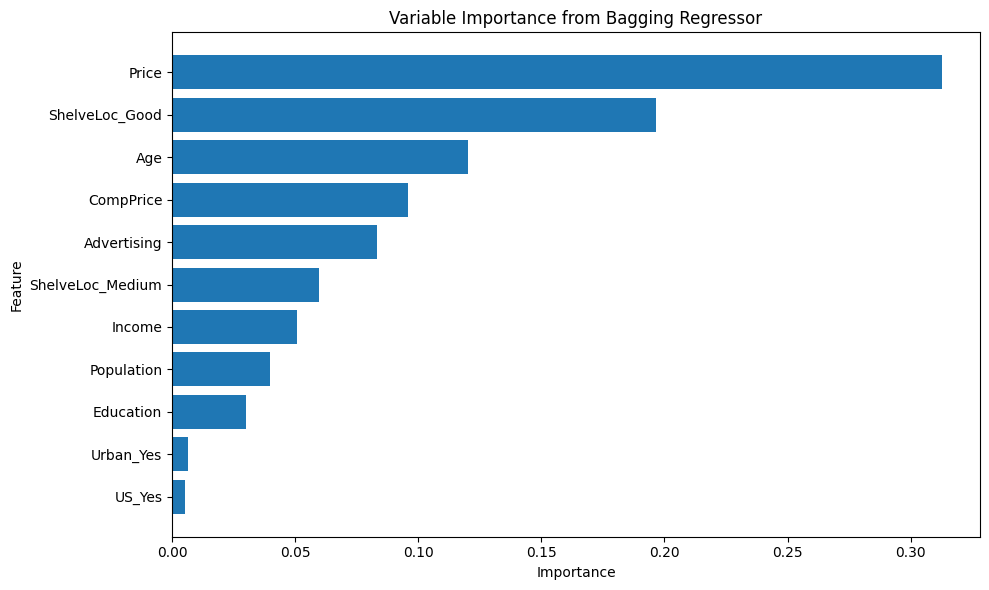

In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import BaggingRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import r2_score

# X_train, X_test, y_train, y_test are assumed to be ready

# Define the bagging model with a decision tree base learner
bag_model = BaggingRegressor(
    estimator=DecisionTreeRegressor(random_state=42),
    random_state=42,
    n_jobs=-1
)

# Search over a range of n_estimators and tree max_depth values
# For BaggingRegressor, parameters of the base tree are written as estimator__...
param_grid = {
    "n_estimators": list(range(50, 301, 10)),
    "estimator__max_depth": list(range(2, 21, 2))
}

# Perform 5-fold cross-validation
grid_search = GridSearchCV(
    estimator=bag_model,
    param_grid=param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

# Fit the grid search
grid_search.fit(X_train, y_train)

# Extract the best model and best parameters
best_params = grid_search.best_params_
final_bag = grid_search.best_estimator_

print("Best parameters:", best_params)
print("Best CV R²:", round(grid_search.best_score_, 4))

# Predict on training and test sets
y_train_pred = final_bag.predict(X_train)
y_test_pred = final_bag.predict(X_test)

# Compute R² values
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

print("Training R²:", round(train_r2, 4))
print("Testing R²:", round(test_r2, 4))

# Average feature importance across all trees
feature_importances = np.mean(
    [tree.feature_importances_ for tree in final_bag.estimators_],
    axis=0
)

# Create a sorted importance table
importance_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": feature_importances
}).sort_values(by="Importance", ascending=False)

print("\nVariable Importance:")
print(importance_df)

# Plot variable importance
plt.figure(figsize=(10, 6))
plt.barh(importance_df["Feature"], importance_df["Importance"])
plt.gca().invert_yaxis()
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Variable Importance from Bagging Regressor")
plt.tight_layout()
plt.show()

### Problem 4

Use boosting to predict Salary in the Hitters data set.


In [26]:
hitters = pd.read_csv('./Hitters.csv', index_col=False)

# check the data
hitters.info()

hitters.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 322 entries, 0 to 321
Data columns (total 20 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   AtBat      322 non-null    int64  
 1   Hits       322 non-null    int64  
 2   HmRun      322 non-null    int64  
 3   Runs       322 non-null    int64  
 4   RBI        322 non-null    int64  
 5   Walks      322 non-null    int64  
 6   Years      322 non-null    int64  
 7   CAtBat     322 non-null    int64  
 8   CHits      322 non-null    int64  
 9   CHmRun     322 non-null    int64  
 10  CRuns      322 non-null    int64  
 11  CRBI       322 non-null    int64  
 12  CWalks     322 non-null    int64  
 13  League     322 non-null    object 
 14  Division   322 non-null    object 
 15  PutOuts    322 non-null    int64  
 16  Assists    322 non-null    int64  
 17  Errors     322 non-null    int64  
 18  Salary     263 non-null    float64
 19  NewLeague  322 non-null    object 
dtypes: float64

,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,League,Division,PutOuts,Assists,Errors,Salary,NewLeague
0,293,66,1,30,29,14,1,293,66,1,30,29,14,A,E,446,33,20,NaN,A
1,315,81,7,24,38,39,14,3449,835,69,321,414,375,N,W,632,43,10,475.0,N
2,479,130,18,66,72,76,3,1624,457,63,224,266,263,A,W,880,82,14,480.0,A
3,496,141,20,65,78,37,11,5628,1575,225,828,838,354,N,E,200,11,3,500.0,N
4,321,87,10,39,42,30,2,396,101,12,48,46,33,N,E,805,40,4,91.5,N


#### Part 0
- Remove the observations for whom the salary information is
unknown, and then log-transform the salaries.
- Create a training set consisting of the first 200 observations, and
a test set consisting of the remaining observations.


In [ ]:
import numpy as np
import pandas as pd

# Remove rows with missing Salary
hitters = hitters.dropna(subset=["Salary"]).copy()

# Log-transform Salary
hitters["Salary"] = np.log(hitters["Salary"])

# Optional: check result
print(hitters.shape)
print(hitters["Salary"].head())

# Create training and test sets (first 200 rows for training, the rest for testing)
train = hitters.iloc[:200].copy()
test = hitters.iloc[200:].copy()

# Separate predictors and response
X_train = train.drop(columns=["Salary"])
y_train = train["Salary"]

X_test = test.drop(columns=["Salary"])
y_test = test["Salary"]

# Check sizes
print("Training set size:", train.shape)
print("Test set size:", test.shape)

(263, 20)
1    6.163315
2    6.173786
3    6.214608
4    4.516339
5    6.620073
Name: Salary, dtype: float64
Training set size: (200, 20)
Test set size: (63, 20)


#### Part 1
- Perform boosting on the training set with 500 trees for a range
of values of the learning rate. 


In [44]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Split into X and y
X_train = train.drop(columns=["Salary"])
y_train = train["Salary"]

X_test = test.drop(columns=["Salary"])
y_test = test["Salary"]

# One-hot encode categorical variables
X_train = pd.get_dummies(X_train, drop_first=True)
X_test = pd.get_dummies(X_test, drop_first=True)

# Make sure train and test have exactly the same columns
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

# Range of learning rates
learning_rates = [0.001, 0.01, 0.05, 0.1, 0.2]

results = []

# Fit boosting model with 500 trees for each learning rate
for lr in learning_rates:
    boost_model = GradientBoostingRegressor(
        n_estimators=500,
        learning_rate=lr,
        random_state=42
    )
    
    boost_model.fit(X_train, y_train)
    
    y_train_pred = boost_model.predict(X_train)
    y_test_pred = boost_model.predict(X_test)
    
    train_mse = mean_squared_error(y_train, y_train_pred)
    test_mse = mean_squared_error(y_test, y_test_pred)
    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)
    
    results.append({
        "learning_rate": lr,
        "train_mse": train_mse,
        "test_mse": test_mse,
        "train_r2": train_r2,
        "test_r2": test_r2
    })

# Put results in a DataFrame
results_df = pd.DataFrame(results)
print(results_df)


   learning_rate     train_mse  test_mse  train_r2   test_r2
0          0.001  3.861491e-01  0.353502  0.535886  0.451622
1          0.010  3.242908e-02  0.209593  0.961023  0.674864
2          0.050  5.778085e-04  0.220342  0.999306  0.658190
3          0.100  9.256491e-06  0.227831  0.999989  0.646571
4          0.200  3.892489e-09  0.259193  1.000000  0.597920


- Produce a plot with different learning rate on the x-axis and the corresponding
training set MSE on the y-axis.

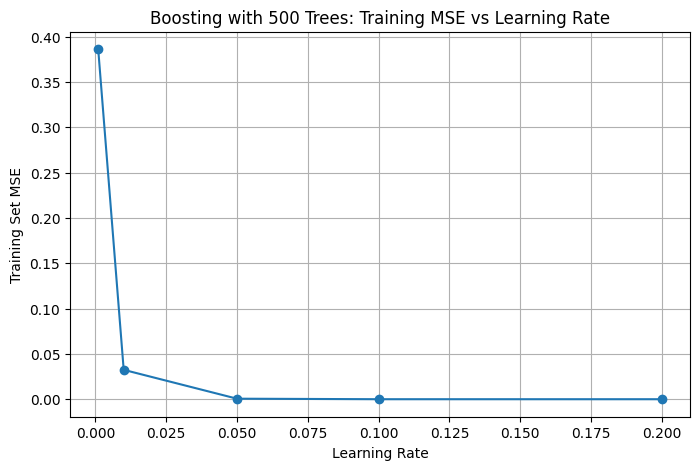

In [29]:
plt.figure(figsize=(8, 5))
plt.plot(results_df["learning_rate"], results_df["train_mse"], marker="o")
plt.xlabel("Learning Rate")
plt.ylabel("Training Set MSE")
plt.title("Boosting with 500 Trees: Training MSE vs Learning Rate")
plt.grid(True)
plt.show()

- Under the best learning rate, what is the MSE on the test set
- Which variables appear to be the most important predictors in
the boosted model?


Results for each learning rate:
   learning_rate     train_mse  test_mse
0          0.001  3.861491e-01  0.353502
1          0.010  3.242908e-02  0.209593
2          0.050  5.778085e-04  0.220342
3          0.100  9.256491e-06  0.227831
4          0.200  3.892489e-09  0.259193

Best learning rate: 0.01
Test MSE at best learning rate: 0.2096

Variable Importance:
        Feature  Importance
7        CAtBat    0.546267
8         CHits    0.093115
10        CRuns    0.051721
0         AtBat    0.048778
5         Walks    0.048182
11         CRBI    0.038846
9        CHmRun    0.032789
12       CWalks    0.032595
6         Years    0.027104
1          Hits    0.024444
4           RBI    0.018200
13      PutOuts    0.012894
3          Runs    0.009681
15       Errors    0.006108
2         HmRun    0.003173
14      Assists    0.003158
18  NewLeague_N    0.001754
16     League_N    0.000675
17   Division_W    0.000514


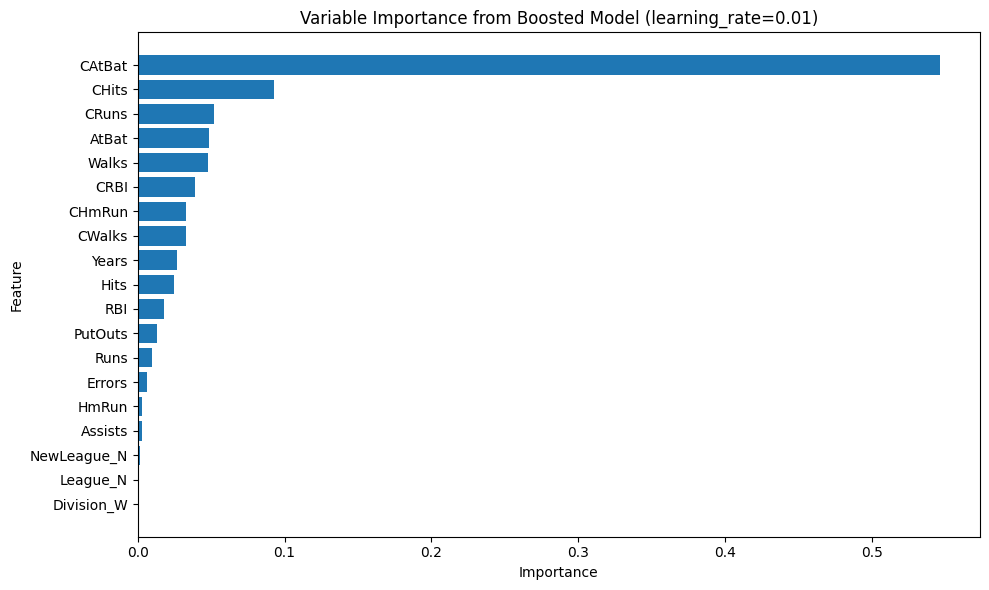


Top 5 most important predictors:
   Feature  Importance
7   CAtBat    0.546267
8    CHits    0.093115
10   CRuns    0.051721
0    AtBat    0.048778
5    Walks    0.048182


In [45]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error

# Try different learning rates with 500 trees
learning_rates = [0.001, 0.01, 0.05, 0.1, 0.2]

results = []

for lr in learning_rates:
    boost_model = GradientBoostingRegressor(
        n_estimators=500,
        learning_rate=lr,
        random_state=42
    )
    boost_model.fit(X_train, y_train)

    y_train_pred = boost_model.predict(X_train)
    y_test_pred = boost_model.predict(X_test)

    train_mse = mean_squared_error(y_train, y_train_pred)
    test_mse = mean_squared_error(y_test, y_test_pred)

    results.append({
        "learning_rate": lr,
        "train_mse": train_mse,
        "test_mse": test_mse
    })

results_df = pd.DataFrame(results)
print("Results for each learning rate:")
print(results_df)

# Find best learning rate based on lowest test MSE
best_idx = results_df["test_mse"].idxmin()
best_lr = results_df.loc[best_idx, "learning_rate"]
best_test_mse = results_df.loc[best_idx, "test_mse"]

print("\nBest learning rate:", best_lr)
print("Test MSE at best learning rate:", round(best_test_mse, 4))

# Fit final boosted model using best learning rate
best_boost_model = GradientBoostingRegressor(
    n_estimators=500,
    learning_rate=best_lr,
    random_state=42
)
best_boost_model.fit(X_train, y_train)

# Variable importance
importance_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": best_boost_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

print("\nVariable Importance:")
print(importance_df)

# Plot variable importance
plt.figure(figsize=(10, 6))
plt.barh(importance_df["Feature"], importance_df["Importance"])
plt.gca().invert_yaxis()
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title(f"Variable Importance from Boosted Model (learning_rate={best_lr})")
plt.tight_layout()
plt.show()

# Top predictors
print("\nTop 5 most important predictors:")
print(importance_df.head(5))

#### Part 2
- Now apply bagging to the training set. Use cross-validation to identify the best bagging model.

Best parameters: {'max_features': 0.5, 'n_estimators': 80}
Best CV MSE: 0.21124077926933388
Training MSE: 0.0319
Test MSE: 0.2275
Training R^2: 0.9617
Test R^2: 0.6471

Variable Importance:
        Feature  Importance
7        CAtBat    0.314720
8         CHits    0.156815
11         CRBI    0.097718
10        CRuns    0.097467
12       CWalks    0.071119
0         AtBat    0.044761
4           RBI    0.036752
5         Walks    0.033713
1          Hits    0.031882
9        CHmRun    0.029044
3          Runs    0.023569
13      PutOuts    0.015488
15       Errors    0.011781
6         Years    0.011040
14      Assists    0.010159
2         HmRun    0.009947
18  NewLeague_N    0.001392
17   Division_W    0.001323
16     League_N    0.001311


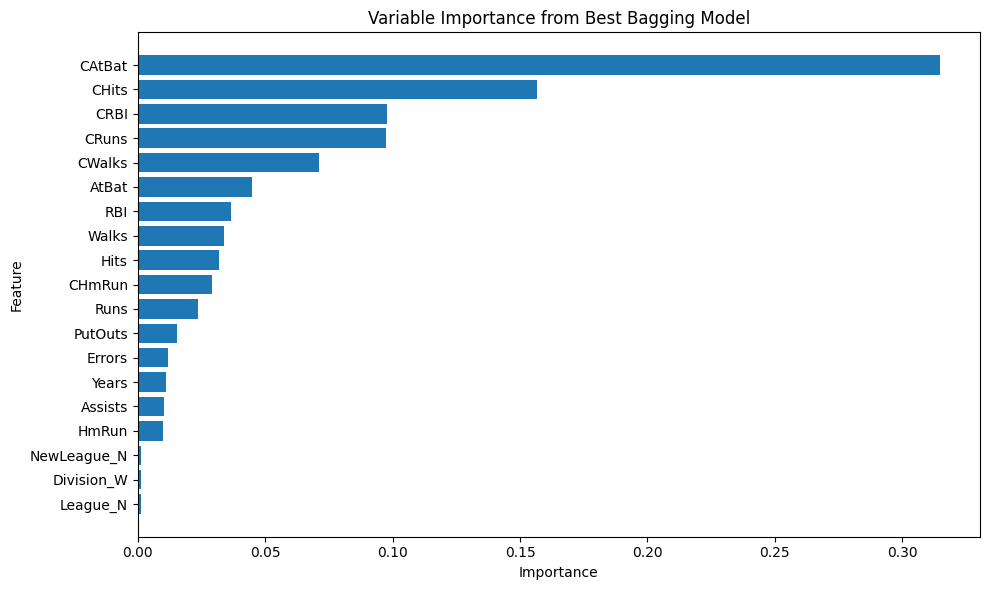

In [46]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import BaggingRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score


# Bagging model
bag = BaggingRegressor(
    estimator=DecisionTreeRegressor(random_state=42),
    random_state=42,
    n_jobs=-1
)

# Cross-validation to choose best bagging model
# We tune the number of trees and the number of features used
param_grid = {
    "n_estimators": list(range(50, 301, 10)),
    "max_features": [0.3, 0.5, 0.7, 1.0]
}

grid_search = GridSearchCV(
    estimator=bag,
    param_grid=param_grid,
    cv=5,
    scoring="neg_mean_squared_error",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

# 5. Best model
best_bag = grid_search.best_estimator_

print("Best parameters:", grid_search.best_params_)
print("Best CV MSE:", -grid_search.best_score_)

# 6. Evaluate on training and test sets
y_train_pred = best_bag.predict(X_train)
y_test_pred = best_bag.predict(X_test)

train_mse = mean_squared_error(y_train, y_train_pred)
test_mse = mean_squared_error(y_test, y_test_pred)

train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

print("Training MSE:", round(train_mse, 4))
print("Test MSE:", round(test_mse, 4))
print("Training R^2:", round(train_r2, 4))
print("Test R^2:", round(test_r2, 4))

# 7. Variable importance
n_features = X_train.shape[1]
all_importances = np.zeros((len(best_bag.estimators_), n_features))

for i, tree in enumerate(best_bag.estimators_):
    feat_idx = best_bag.estimators_features_[i]
    all_importances[i, feat_idx] = tree.feature_importances_

feature_importances = all_importances.mean(axis=0)

importance_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": feature_importances
}).sort_values(by="Importance", ascending=False)

print("\nVariable Importance:")
print(importance_df)

# 8. Plot variable importance
plt.figure(figsize=(10, 6))
plt.barh(importance_df["Feature"], importance_df["Importance"])
plt.gca().invert_yaxis()
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Variable Importance from Best Bagging Model")
plt.tight_layout()
plt.show()

- What is the test set MSE
for this approach
- Which variable is the most important?

In [47]:
print("Test set MSE for bagging:", round(test_mse, 4))
print("Most important variable:", importance_df.iloc[0]["Feature"])


Test set MSE for bagging: 0.2275
Most important variable: CAtBat


### Reference: An introduction to Statistical Learning with Application in R